In [2]:
import numpy as np
from scipy.optimize import fsolve
import sympy as sp

Se realizan los DCL para los 5 ejes del sistema. Se definen como elemento a iterar las distancias entre cada cojinete y se considerará el qu etenga mayor solicitud para el diseño del sistema.

In [3]:
def resolver_sistema_lineal(A, b):
    """
    Resuelve el sistema de ecuaciones lineales Ax = b
    
    Args:
        A: Matriz de coeficientes (numpy array)
        b: Vector de términos independientes (numpy array)
    
    Returns:
        x: Vector solución
    """
    # Verificar que el sistema tiene solución única
    if np.linalg.det(A) == 0:
        print("ADVERTENCIA: La matriz es singular, el sistema puede no tener solución única")
    
    x = np.linalg.solve(A, b)
    return x

## Sector A

In [17]:
#Codigo implementado con ayuda de IA
# Parámetros MODIFICAR
a = 100e-3  # m
b = 100e-3  # m  
c = 100e-3  # m

# TORQUES HORARIOS (negativos por convención)
Ti = -254.35  # N·m (horario)
Tm = -483.74  # N·m (horario)

# FUERZAS RADIALES 
Fix = 0      # Componente X de Fi (N)
Fiy = 25.35 / 50e-3  # Componente Y de Fi (N)  
Ftx = 0      # Componente X de Ft (N)
Fty = (357/6) * 53.37  # Componente Y de Ft (N)

# MATRIZ CON PIVOTE EN B
A = np.array([
    # Rax  Ray  Raz  Rbx  Rby  Rbz
    [ 1,   0,   0,   1,   0,   0],    # ΣFx = 0
    [ 0,   1,   0,   0,   1,   0],    # ΣFy = 0
    [ 0,   0,   1,   0,   0,   1],    # ΣFz = 0
    [ 0,  -b,   0,   0,   0,   0],    # ΣMx(B) = -b*Ray + [...]
    [ b,   0,   0,   0,   0,   0],    # ΣMy(B) = b*Rax + [...]
    [ 0,   0,   0,   0,   0,   0]     # ΣMz(B) = (-Ti + Tm)
])

# VECTOR DE TÉRMINOS INDEPENDIENTES
B = np.array([
    -Fix - Ftx,                   # ΣFx
    -Fiy - Fty,                   # ΣFy  
    0,                            # ΣFz
    -(-Fiy*(a+b) + Fty*c),        # ΣMx(B)
    -(Fix*(a+b) - Ftx*c),         # ΣMy(B)
    -(-Ti + Tm)                   # ΣMz(B)
])

print("=== ANÁLISIS CON TORQUES HORARIOS ===")
print(f"Ti = {Ti} N·m (horario)")
print(f"Tm = {Tm} N·m (horario)")
print(f"ΣMz = -Ti + Tm = {-Ti + Tm:.2f} N·m")

print("\nMatriz A:")
print(A)

# RESOLVER SISTEMA
print(f"\nDeterminante: {np.linalg.det(A):.6f}")

if np.linalg.det(A) != 0:
    solucionA = np.linalg.solve(A, B)
    print("\n--- SOLUCIÓN ---")
    print(f"Rax = {solucionA[0]:.2f} N")
    print(f"Ray = {solucionA[1]:.2f} N") 
    print(f"Raz = {solucionA[2]:.2f} N")
    print(f"Rbx = {solucionA[3]:.2f} N")
    print(f"Rby = {solucionA[4]:.2f} N")
    print(f"Rbz = {solucionA[5]:.2f} N")
    
    # VERIFICACIÓN
    print("\n--- VERIFICACIÓN ---")
    print(f"ΣFx = {solucionA[0] + solucionA[3] + Fix + Ftx:.6f} N")
    print(f"ΣFy = {solucionA[1] + solucionA[4] + Fiy + Fty:.6f} N")
    print(f"ΣFz = {solucionA[2] + solucionA[5]:.6f} N")
    print(f"ΣMx(B) = {-b*solucionA[1] + (-Fiy*(a+b) + Fty*c):.6f} N·m")
    print(f"ΣMy(B) = {b*solucionA[0] + (Fix*(a+b) - Ftx*c):.6f} N·m")
    print(f"ΣMz(B) = {-Ti + Tm:.6f} N·m")
    
else:
    print("Matriz singular - usando pseudoinversa")
    solucionA = np.linalg.lstsq(A, B, rcond=None)[0]
    print("\nSolución aproximada:")
    print(f"Rax = {solucionA[0]:.2f} N")
    print(f"Ray = {solucionA[1]:.2f} N")
    print(f"Raz = {solucionA[2]:.2f} N")
    print(f"Rbx = {solucionA[3]:.2f} N")
    print(f"Rby = {solucionA[4]:.2f} N")
    print(f"Rbz = {solucionA[5]:.2f} N")

# ANÁLISIS DEL TORQUE
print("\n--- ANÁLISIS DE TORQUE ---")
desequilibrio = -Ti + Tm
if abs(desequilibrio) < 1e-6:
    print("✓ Sistema en equilibrio de torque")
else:
    print(f"✗ Desequilibrio de torque: {desequilibrio:.2f} N·m")
    print("El árbol está acelerando/desacelerando")

=== ANÁLISIS CON TORQUES HORARIOS ===
Ti = -254.35 N·m (horario)
Tm = -483.74 N·m (horario)
ΣMz = -Ti + Tm = -229.39 N·m

Matriz A:
[[ 1.   0.   0.   1.   0.   0. ]
 [ 0.   1.   0.   0.   1.   0. ]
 [ 0.   0.   1.   0.   0.   1. ]
 [ 0.  -0.1  0.   0.   0.   0. ]
 [ 0.1  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0. ]]

Determinante: 0.000000
Matriz singular - usando pseudoinversa

Solución aproximada:
Rax = 0.00 N
Ray = 2161.51 N
Raz = 0.00 N
Rbx = 0.00 N
Rby = -5844.03 N
Rbz = 0.00 N

--- ANÁLISIS DE TORQUE ---
✗ Desequilibrio de torque: -229.39 N·m
El árbol está acelerando/desacelerando


## Sector B

### Caso marcha 2

In [ ]:
#Codigo implementado con ayuda de IA
# Parámetros MODIFICAR
a = 100e-3  # m
b = 100e-3  # m  
c = 100e-3  # m
d = 100e-3  # m

# Fuerzas de engranes
F1y = 242.11*2/(242.49e-3)  # N
F1x = F1y * np.tan(np.radians(20))  # N
F1z = F1y * np.tan(np.radians(30))  # N

F2y = 0*2/(103.92e-3)  # N
F2x = F2y * np.tan(np.radians(20))  # N
F2z = F2y * np.tan(np.radians(30))  # N


# FUERZAS RADIALES 
Ftx = 0      # Componente X de Ft (N)
Fty = (357/6) * 53.37  # Componente Y de Ft (N)

# MATRIZ CON PIVOTE EN B
A = np.array([
    # Rax  Ray  Raz  Rbx  Rby  Rbz
    [ 1,   0,   0,   1,   0,   0],    # ΣFx = 0
    [ 0,   1,   0,   0,   1,   0],    # ΣFy = 0
    [ 0,   0,   1,   0,   0,   1],    # ΣFz = 0
    [ 0,  -(b+c+d),   0,   0,   0,   0],    # ΣMx(B) = -b*Ray + [...]
    [ (b+c+d),   0,   0,   0,   0,   0],    # ΣMy(B) = b*Rax + [...]
    [ 0,   0,   0,   0,   0,   0]     # ΣMz(B) = (-Ti + Tm)
])

# VECTOR DE TÉRMINOS INDEPENDIENTES
B = np.array([
    F1x + F1x,                   # ΣFx
    Fty - (F1y + F2y),                   # ΣFy  
    F2z - F1z,                            # ΣFz
    F1y*(c+d) + F2y*d - Fty*(a+b+c+d),        # ΣMx(B)
    F1x*(c+d) + F2x*d,         # ΣMy(B)
    -(Tm + F1y *242.49e-3 + F2y * 103.92e-3)                   # ΣMz(B)
])

print("=== ANÁLISIS CON TORQUES HORARIOS ===")
print(f"Ti = {Ti} N·m (horario)")
print(f"Tm = {Tm} N·m (horario)")
print(f"ΣMz = -Ti + Tm = {-Ti + Tm:.2f} N·m")

print("\nMatriz A:")
print(A)

# RESOLVER SISTEMA
print(f"\nDeterminante: {np.linalg.det(A):.6f}")

if np.linalg.det(A) != 0:
    solucion = np.linalg.solve(A, B)
    print("\n--- SOLUCIÓN ---")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N") 
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")
    
    # VERIFICACIÓN
    print("\n--- VERIFICACIÓN ---")
    print(f"ΣFx = {solucion[0] + solucion[3] + Fix + Ftx:.6f} N")
    print(f"ΣFy = {solucion[1] + solucion[4] + Fiy + Fty:.6f} N")
    print(f"ΣFz = {solucion[2] + solucion[5]:.6f} N")
    print(f"ΣMx(B) = {-b*solucion[1] + (-Fiy*(a+b) + Fty*c):.6f} N·m")
    print(f"ΣMy(B) = {b*solucion[0] + (Fix*(a+b) - Ftx*c):.6f} N·m")
    print(f"ΣMz(B) = {-Ti + Tm:.6f} N·m")
    
else:
    print("Matriz singular - usando pseudoinversa")
    solucion = np.linalg.lstsq(A, B, rcond=None)[0]
    print("\nSolución aproximada:")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N")
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")

# ANÁLISIS DEL TORQUE
print("\n--- ANÁLISIS DE TORQUE ---")
desequilibrio = -Ti + Tm
if abs(desequilibrio) < 1e-6:
    print("✓ Sistema en equilibrio de torque")
else:
    print(f"✗ Desequilibrio de torque: {desequilibrio:.2f} N·m")
    print("El árbol está acelerando/desacelerando")

=== ANÁLISIS CON TORQUES HORARIOS ===
Ti = -254.35 N·m (horario)
Tm = -483.74 N·m (horario)
ΣMz = -Ti + Tm = -229.39 N·m

Matriz A:
[[ 1.   0.   0.   1.   0.   0. ]
 [ 0.   1.   0.   0.   1.   0. ]
 [ 0.   0.   1.   0.   0.   1. ]
 [ 0.  -0.3  0.   0.   0.   0. ]
 [ 0.3  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0. ]]

Determinante: 0.000000
Matriz singular - usando pseudoinversa

Solución aproximada:
Rax = 484.53 N
Ray = 2902.78 N
Raz = -576.45 N
Rbx = 969.07 N
Rby = -1724.13 N
Rbz = -576.45 N

--- ANÁLISIS DE TORQUE ---
✗ Desequilibrio de torque: -229.39 N·m
El árbol está acelerando/desacelerando


### Caso marcha 1

In [19]:
#Codigo implementado con ayuda de IA
# Parámetros MODIFICAR
a = 100e-3  # m
b = 100e-3  # m  
c = 100e-3  # m
d = 100e-3  # m

# Fuerzas de engranes
F1y = 0*2/(242.49e-3)  # N
F1x = F1y * np.tan(np.radians(20))  # N
F1z = F1y * np.tan(np.radians(30))  # N

F2y = 242.11*2/(103.92e-3)  # N
F2x = F2y * np.tan(np.radians(20))  # N
F2z = F2y * np.tan(np.radians(30))  # N


# FUERZAS RADIALES 
Ftx = 0      # Componente X de Ft (N)
Fty = (357/6) * 53.37  # Componente Y de Ft (N)

# MATRIZ CON PIVOTE EN B
A = np.array([
    # Rax  Ray  Raz  Rbx  Rby  Rbz
    [ 1,   0,   0,   1,   0,   0],    # ΣFx = 0
    [ 0,   1,   0,   0,   1,   0],    # ΣFy = 0
    [ 0,   0,   1,   0,   0,   1],    # ΣFz = 0
    [ 0,  -(b+c+d),   0,   0,   0,   0],    # ΣMx(B) = -b*Ray + [...]
    [ (b+c+d),   0,   0,   0,   0,   0],    # ΣMy(B) = b*Rax + [...]
    [ 0,   0,   0,   0,   0,   0]     # ΣMz(B) = (-Ti + Tm)
])

# VECTOR DE TÉRMINOS INDEPENDIENTES
B = np.array([
    F1x + F1x,                   # ΣFx
    Fty - (F1y + F2y),                   # ΣFy  
    F2z - F1z,                            # ΣFz
    F1y*(c+d) + F2y*d - Fty*(a+b+c+d),        # ΣMx(B)
    F1x*(c+d) + F2x*d,         # ΣMy(B)
    -(Tm + F1y *242.49e-3 + F2y * 103.92e-3)                   # ΣMz(B)
])

print("=== ANÁLISIS CON TORQUES HORARIOS ===")
print(f"Ti = {Ti} N·m (horario)")
print(f"Tm = {Tm} N·m (horario)")
print(f"ΣMz = -Ti + Tm = {-Ti + Tm:.2f} N·m")

print("\nMatriz A:")
print(A)

# RESOLVER SISTEMA
print(f"\nDeterminante: {np.linalg.det(A):.6f}")

if np.linalg.det(A) != 0:
    solucion = np.linalg.solve(A, B)
    print("\n--- SOLUCIÓN ---")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N") 
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")
    
    # VERIFICACIÓN
    print("\n--- VERIFICACIÓN ---")
    print(f"ΣFx = {solucion[0] + solucion[3] + Fix + Ftx:.6f} N")
    print(f"ΣFy = {solucion[1] + solucion[4] + Fiy + Fty:.6f} N")
    print(f"ΣFz = {solucion[2] + solucion[5]:.6f} N")
    print(f"ΣMx(B) = {-b*solucion[1] + (-Fiy*(a+b) + Fty*c):.6f} N·m")
    print(f"ΣMy(B) = {b*solucion[0] + (Fix*(a+b) - Ftx*c):.6f} N·m")
    print(f"ΣMz(B) = {-Ti + Tm:.6f} N·m")
    
else:
    print("Matriz singular - usando pseudoinversa")
    solucion = np.linalg.lstsq(A, B, rcond=None)[0]
    print("\nSolución aproximada:")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N")
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")

# ANÁLISIS DEL TORQUE
print("\n--- ANÁLISIS DE TORQUE ---")
desequilibrio = -Ti + Tm
if abs(desequilibrio) < 1e-6:
    print("✓ Sistema en equilibrio de torque")
else:
    print(f"✗ Desequilibrio de torque: {desequilibrio:.2f} N·m")
    print("El árbol está acelerando/desacelerando")

=== ANÁLISIS CON TORQUES HORARIOS ===
Ti = -254.35 N·m (horario)
Tm = -483.74 N·m (horario)
ΣMz = -Ti + Tm = -229.39 N·m

Matriz A:
[[ 1.   0.   0.   1.   0.   0. ]
 [ 0.   1.   0.   0.   1.   0. ]
 [ 0.   0.   1.   0.   0.   1. ]
 [ 0.  -0.3  0.   0.   0.   0. ]
 [ 0.3  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0. ]]

Determinante: 0.000000
Matriz singular - usando pseudoinversa

Solución aproximada:
Rax = 565.31 N
Ray = 2680.84 N
Raz = 1345.10 N
Rbx = -565.31 N
Rby = -4164.87 N
Rbz = 1345.10 N

--- ANÁLISIS DE TORQUE ---
✗ Desequilibrio de torque: -229.39 N·m
El árbol está acelerando/desacelerando


## Sector C

### Caso marcha 2

In [22]:
#Codigo implementado con ayuda de IA
# Parámetros MODIFICAR
a = 100e-3  # m
b = 100e-3  # m  
c = 100e-3  # m
d = 100e-3  # m

# Fuerzas de engranes
F1y = 484.22*2/(121.24e-3)  # N
F1x = F1y * np.tan(np.radians(20))  # N
F1z = F1y * np.tan(np.radians(30))  # N

F2y = 0*2/(259.81e-3)  # N
F2x = F2y * np.tan(np.radians(20))  # N
F2z = F2y * np.tan(np.radians(30))  # N




# MATRIZ CON PIVOTE EN B
A = np.array([
    # Rax  Ray  Raz  Rdx  Rdy  Rdz
    [ 1,   0,   0,   1,   0,   0],    # ΣFx = 0
    [ 0,   1,   0,   0,   1,   0],    # ΣFy = 0
    [ 0,   0,   1,   0,   0,   1],    # ΣFz = 0
    [ 0,  -(b+c+a),   0,   0,   0,   0],    # ΣMx(B) = -b*Ray + [...]
    [ (b+c+a),   0,   0,   0,   0,   0],    # ΣMy(B) = b*Rax + [...]
    [ 0,   0,   0,   0,   0,   0]     # ΣMz(B) = (-Ti + Tm)
])

# VECTOR DE TÉRMINOS INDEPENDIENTES
B = np.array([
    -F1x - F1x,                   # ΣFx
    - (F1y + F2y),                   # ΣFy  
    F2z - F1z,                            # ΣFz
    F1y*(c+b) + F2y*c,        # ΣMx(B)
    -F1x*(c+b) - F2x*c,         # ΣMy(B)
    -(F1y *121.24e-3 + F2y * 259.81e-3)                   # ΣMz(B)
])

print("=== ANÁLISIS CON TORQUES HORARIOS ===")
print(f"Ti = {Ti} N·m (horario)")
print(f"Tm = {Tm} N·m (horario)")
print(f"ΣMz = -Ti + Tm = {-Ti + Tm:.2f} N·m")

print("\nMatriz A:")
print(A)

# RESOLVER SISTEMA
print(f"\nDeterminante: {np.linalg.det(A):.6f}")

if np.linalg.det(A) != 0:
    solucion = np.linalg.solve(A, B)
    print("\n--- SOLUCIÓN ---")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N") 
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")
    
    # VERIFICACIÓN
    print("\n--- VERIFICACIÓN ---")
    print(f"ΣFx = {solucion[0] + solucion[3] + Fix + Ftx:.6f} N")
    print(f"ΣFy = {solucion[1] + solucion[4] + Fiy + Fty:.6f} N")
    print(f"ΣFz = {solucion[2] + solucion[5]:.6f} N")
    print(f"ΣMx(B) = {-b*solucion[1] + (-Fiy*(a+b) + Fty*c):.6f} N·m")
    print(f"ΣMy(B) = {b*solucion[0] + (Fix*(a+b) - Ftx*c):.6f} N·m")
    print(f"ΣMz(B) = {-Ti + Tm:.6f} N·m")
    
else:
    print("Matriz singular - usando pseudoinversa")
    solucion = np.linalg.lstsq(A, B, rcond=None)[0]
    print("\nSolución aproximada:")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N")
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")
    print(f'F1x: {F1x:.2f}, F1y: {F1y:.2f}, F1z: {F1z:.2f}')

# ANÁLISIS DEL TORQUE
print("\n--- ANÁLISIS DE TORQUE ---")
desequilibrio = -Ti + Tm
if abs(desequilibrio) < 1e-6:
    print("✓ Sistema en equilibrio de torque")
else:
    print(f"✗ Desequilibrio de torque: {desequilibrio:.2f} N·m")
    print("El árbol está acelerando/desacelerando")

=== ANÁLISIS CON TORQUES HORARIOS ===
Ti = -254.35 N·m (horario)
Tm = -483.74 N·m (horario)
ΣMz = -Ti + Tm = -229.39 N·m

Matriz A:
[[ 1.   0.   0.   1.   0.   0. ]
 [ 0.   1.   0.   0.   1.   0. ]
 [ 0.   0.   1.   0.   0.   1. ]
 [ 0.  -0.3  0.   0.   0.   0. ]
 [ 0.3  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0. ]]

Determinante: 0.000000
Matriz singular - usando pseudoinversa

Solución aproximada:
Rax = -1938.21 N
Ray = -5325.20 N
Raz = -2305.88 N
Rbx = -3876.43 N
Rby = -2662.60 N
Rbz = -2305.88 N
F1x: 2907.32, F1y: 7987.79, F1z: 4611.75

--- ANÁLISIS DE TORQUE ---
✗ Desequilibrio de torque: -229.39 N·m
El árbol está acelerando/desacelerando


### Caso marcha 1

In [24]:
#Codigo implementado con ayuda de IA
# Parámetros MODIFICAR
a = 100e-3  # m
b = 100e-3  # m  
c = 100e-3  # m
d = 100e-3  # m

# Fuerzas de engranes
F1y = 0*2/(121.24e-3)  # N
F1x = F1y * np.tan(np.radians(20))  # N
F1z = F1y * np.tan(np.radians(30))  # N

F2y = 605.28*2/(259.81e-3)  # N
F2x = F2y * np.tan(np.radians(20))  # N
F2z = F2y * np.tan(np.radians(30))  # N




# MATRIZ CON PIVOTE EN B
A = np.array([
    # Rax  Ray  Raz  Rdx  Rdy  Rdz
    [ 1,   0,   0,   1,   0,   0],    # ΣFx = 0
    [ 0,   1,   0,   0,   1,   0],    # ΣFy = 0
    [ 0,   0,   1,   0,   0,   1],    # ΣFz = 0
    [ 0,  -(b+c+a),   0,   0,   0,   0],    # ΣMx(B) = -b*Ray + [...]
    [ (b+c+a),   0,   0,   0,   0,   0],    # ΣMy(B) = b*Rax + [...]
    [ 0,   0,   0,   0,   0,   0]     # ΣMz(B) = (-Ti + Tm)
])

# VECTOR DE TÉRMINOS INDEPENDIENTES
B = np.array([
    -F1x - F1x,                   # ΣFx
    - (F1y + F2y),                   # ΣFy  
    F2z - F1z,                            # ΣFz
    F1y*(c+b) + F2y*c,        # ΣMx(B)
    -F1x*(c+b) - F2x*c,         # ΣMy(B)
    -(F1y *121.24e-3 + F2y * 259.81e-3)                   # ΣMz(B)
])

print("=== ANÁLISIS CON TORQUES HORARIOS ===")
print(f"Ti = {Ti} N·m (horario)")
print(f"Tm = {Tm} N·m (horario)")
print(f"ΣMz = -Ti + Tm = {-Ti + Tm:.2f} N·m")

print("\nMatriz A:")
print(A)

# RESOLVER SISTEMA
print(f"\nDeterminante: {np.linalg.det(A):.6f}")

if np.linalg.det(A) != 0:
    solucion = np.linalg.solve(A, B)
    print("\n--- SOLUCIÓN ---")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N") 
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")
    
    # VERIFICACIÓN
    print("\n--- VERIFICACIÓN ---")
    print(f"ΣFx = {solucion[0] + solucion[3] + Fix + Ftx:.6f} N")
    print(f"ΣFy = {solucion[1] + solucion[4] + Fiy + Fty:.6f} N")
    print(f"ΣFz = {solucion[2] + solucion[5]:.6f} N")
    print(f"ΣMx(B) = {-b*solucion[1] + (-Fiy*(a+b) + Fty*c):.6f} N·m")
    print(f"ΣMy(B) = {b*solucion[0] + (Fix*(a+b) - Ftx*c):.6f} N·m")
    print(f"ΣMz(B) = {-Ti + Tm:.6f} N·m")
    
else:
    print("Matriz singular - usando pseudoinversa")
    solucion = np.linalg.lstsq(A, B, rcond=None)[0]
    print("\nSolución aproximada:")
    print(f"Rax = {solucion[0]:.2f} N")
    print(f"Ray = {solucion[1]:.2f} N")
    print(f"Raz = {solucion[2]:.2f} N")
    print(f"Rbx = {solucion[3]:.2f} N")
    print(f"Rby = {solucion[4]:.2f} N")
    print(f"Rbz = {solucion[5]:.2f} N")
    print(f'F2x: {F2x:.2f}, F2y: {F2y:.2f}, F2z: {F2z:.2f}')

# ANÁLISIS DEL TORQUE
print("\n--- ANÁLISIS DE TORQUE ---")
desequilibrio = -Ti + Tm
if abs(desequilibrio) < 1e-6:
    print("✓ Sistema en equilibrio de torque")
else:
    print(f"✗ Desequilibrio de torque: {desequilibrio:.2f} N·m")
    print("El árbol está acelerando/desacelerando")

=== ANÁLISIS CON TORQUES HORARIOS ===
Ti = -254.35 N·m (horario)
Tm = -483.74 N·m (horario)
ΣMz = -Ti + Tm = -229.39 N·m

Matriz A:
[[ 1.   0.   0.   1.   0.   0. ]
 [ 0.   1.   0.   0.   1.   0. ]
 [ 0.   0.   1.   0.   0.   1. ]
 [ 0.  -0.3  0.   0.   0.   0. ]
 [ 0.3  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0. ]]

Determinante: 0.000000
Matriz singular - usando pseudoinversa

Solución aproximada:
Rax = -565.29 N
Ray = -1553.13 N
Raz = 1345.05 N
Rbx = 565.29 N
Rby = -3106.27 N
Rbz = 1345.05 N
F2x: 1695.88, F2y: 4659.40, F2z: 2690.11

--- ANÁLISIS DE TORQUE ---
✗ Desequilibrio de torque: -229.39 N·m
El árbol está acelerando/desacelerando


## Sector D

In [48]:
T = 85 * 745.7  / 666.7 # Convertir HP a W

Fay = T / 510.01e-3  # N

print(f"\nFuerza axial en el rodamiento Fay: {Fay:.2f} N")


Fuerza axial en el rodamiento Fay: 186.41 N


-----

# Definición de rodamientos

Para esta parte buscamos obtener la fuerza dada la ecuación de Weibull, para eso requerimos de las revoluciones de cada sector, donde sector A y B tendrán mismas RPM, mientras que para el C y el D esto dependerá de la marcha utilizada. 

El parametro $X_D$ se obtendrá de la siguiente manera:

$X_D = \frac{60\cdot Vida \cdot RPM}{10^{6}} = \frac{60\cdot 4160 \cdot RPM}{10^{6}}$

Por lo que para A y B

$X_{D,A} = X_{D,B} = \frac{60\cdot 4160 \cdot 2500}{10^{6}} = 624$

Para C marcha 2:
$X_{D,C1} = \frac{60\cdot 4160 \cdot 1250}{10^{6}} = 312$

Para C marcha 1:
$X_{D,C2} = \frac{60\cdot 4160 \cdot 1000}{10^{6}} = 249.6$


Para D marcha 2:
$X_{D,D1} = \frac{60\cdot 4160 \cdot 833.3}{10^{6}} = 207.99$

Para D marcha 1:
$X_{D,D2} = \frac{60\cdot 4160 \cdot 666.67}{10^{6}} = 166.4$

Ahora debemos establecer el factor de carga a utilizar

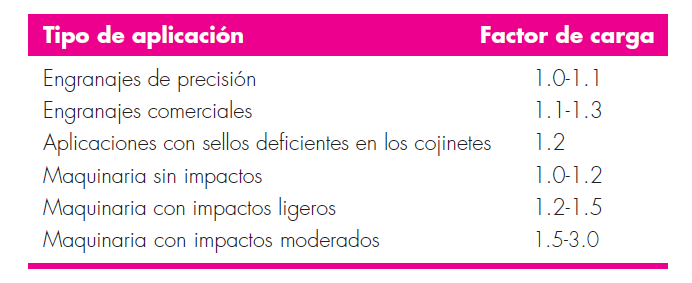

Para ello es apropiado utilizar 1.5 dado que estamos trabajando con una guillotina industrial.

Finalmente, la ecuación de Weibull a utilizar será:

$C = 1.5 F_d (\frac{X_D}{0.02+4.439(1-0.99)^{1.483}})^{1/3}$

In [52]:
def Weibull(Fd, Xd):
    return 1.5 * Fd * (Xd / (0.02+4.439*np.log(1/0.99)**(1/1.483)))**(1/3)

def Weibull_rodillo(Fd, Xd):
    return 1.5 * Fd * (Xd / (0.02+4.439*np.log(1/0.99)**(1/1.483)))**(3/10)

TABLA BOLAS

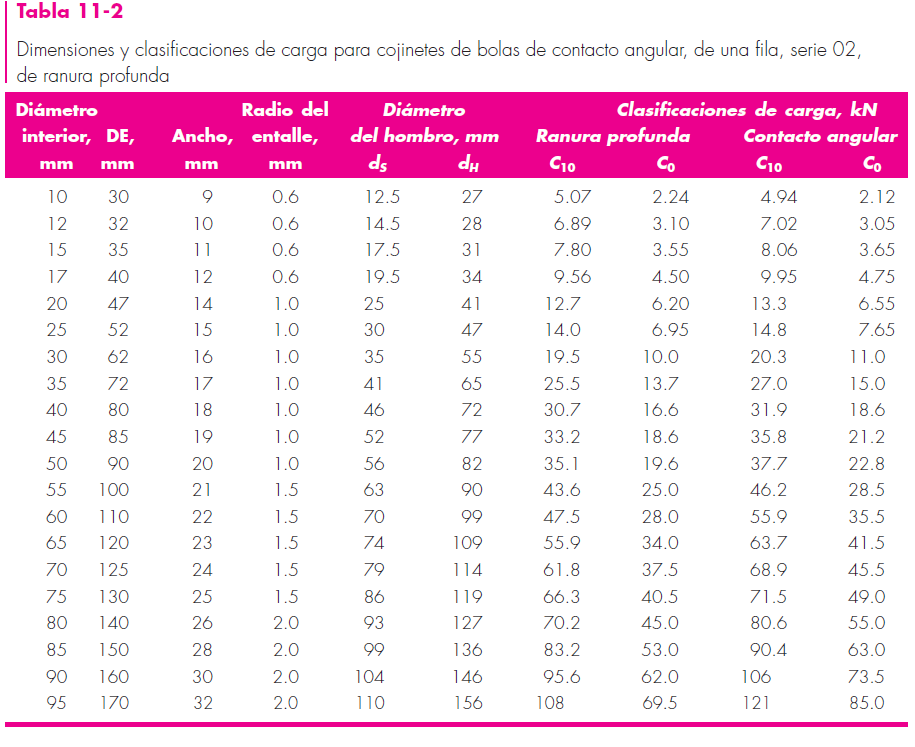

TABLA CILINDRICOS 

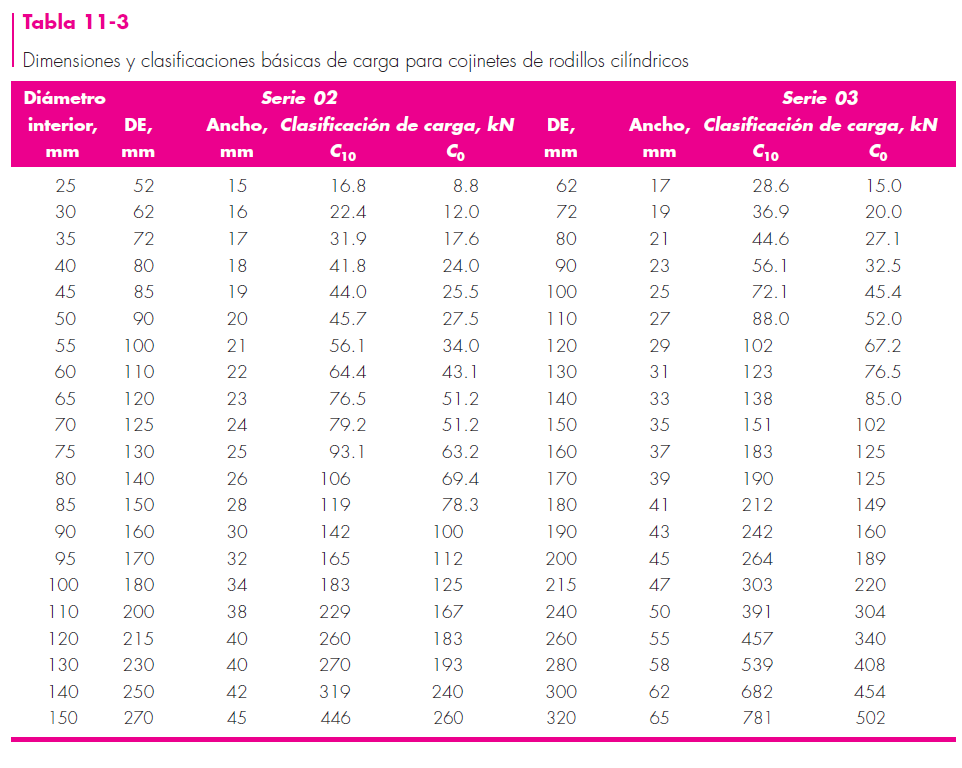

## Sector A

In [43]:
FdA = np.sqrt(0**2+5844.3**2)  # N
XdA = 624
print(f"Weibull en A: {Weibull(FdA, XdA)*1e-3:.2f} kN")

Weibull en A: 124.17 kN


El valor supera a los de la tabla, por lo que el rodamiento seleccionado debe ser de rodillo:

In [53]:
FdA = np.sqrt(0**2+5844.3**2)  # N
XdA = 624
print(f"Weibull en A: {Weibull_rodillo(FdA, XdA)*1e-3:.2f} kN")

Weibull en A: 95.26 kN


Se seleeciona el valor más cercano correspondiente al rodamiento de rodillo de diametro 75 mm interior Serie 02

## Sector B

In [45]:
## Marcha 2
FdB2 = max(np.sqrt( 484.53**2+2902.78**2), np.sqrt(969.07**2+1724.13**2))  # N
XdB2 = 624
print(f"Weibull en B (marcha 2): {Weibull(FdB2, XdB2)*1e-3:.2f} kN")

##Marcha 1
FdB1 = max(np.sqrt(565.31**2+2680.84**2), np.sqrt(565.31**2+4164.87**2))  # N
XdB1 = 624
print(f"Weibull en B (marcha 1): {Weibull(FdB1, XdB1)*1e-3:.2f} kN")

Weibull en B (marcha 2): 62.53 kN
Weibull en B (marcha 1): 89.30 kN


Se selecciona el valor más cercano correspondiente al rodamiento de bolas diametro 85 mm interior Serie 02

## Sector C

In [47]:
## Marcha 2
FdC2 = max(np.sqrt(1938.21**2+5325.20**2), np.sqrt(3876.43**2+2662.603**2), np.sqrt(2907.32**2 + 7987.79**2))  # N
XdC2 = 312
print(f"Weibull en C (marcha 2): {Weibull(FdC2, XdC2)*1e-3:.2f} kN")

##Marcha 1
FdC1 = max(np.sqrt(565.29**2+1553.13**2), np.sqrt(565.29**2+3106.27**2), np.sqrt(1695.88**2 + 4659.40**2))  # N
XdC1 = 312
print(f"Weibull en C (marcha 1): {Weibull(FdC1, XdC1)*1e-3:.2f} kN")

Weibull en C (marcha 2): 143.34 kN
Weibull en C (marcha 1): 83.61 kN


Se toma el caso más critico y este supera los datos del de bolas, por lo tanto se calcula como rodillo:

In [54]:
## Marcha 2
FdC2 = max(np.sqrt(1938.21**2+5325.20**2), np.sqrt(3876.43**2+2662.603**2), np.sqrt(2907.32**2 + 7987.79**2))  # N
XdC2 = 312
print(f"Weibull en C (marcha 2): {Weibull_rodillo(FdC2, XdC2)*1e-3:.2f} kN")

Weibull en C (marcha 2): 112.54 kN


Se seleeciona el valor más cercano correspondiente al rodamiento de diametro 80 mm interior Serie 02

## Sector D

In [49]:
FdD = 186.41
XdC1 = 166.4
print(f"Weibull en D: {Weibull(FdD, XdC1)*1e-3:.2f} kN")

Weibull en D: 2.55 kN


Se selecciona el valor más cercano correspondiente al rodamiento de bolas diametro 10 mm interior Serie 02